In [1]:
#data structures
import pandas as pd
import numpy as np

#machine learning

#metrics (performace and machine learning scores)
import time #used for seeing how long it takes to run programs

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [2]:
df = pd.read_csv('diabetes_012.csv') #The data values of each building
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## Exploration of data:

In [5]:
featureList = df.drop(['Diabetes_012'], axis = 1).columns.tolist()

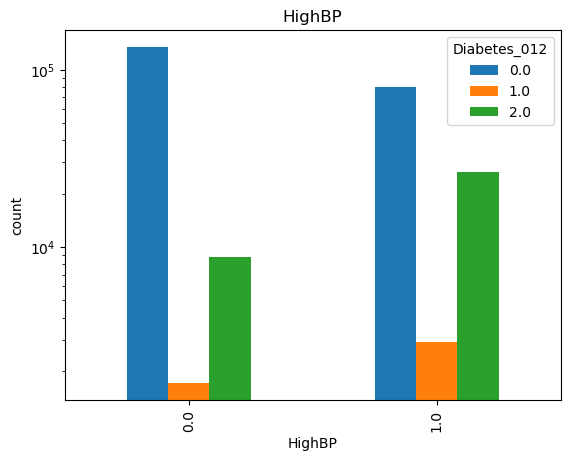

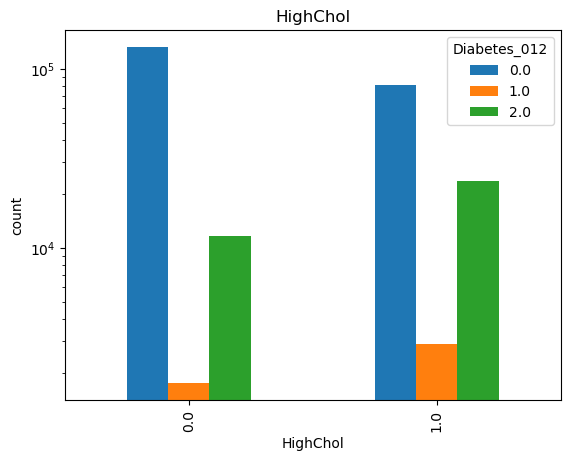

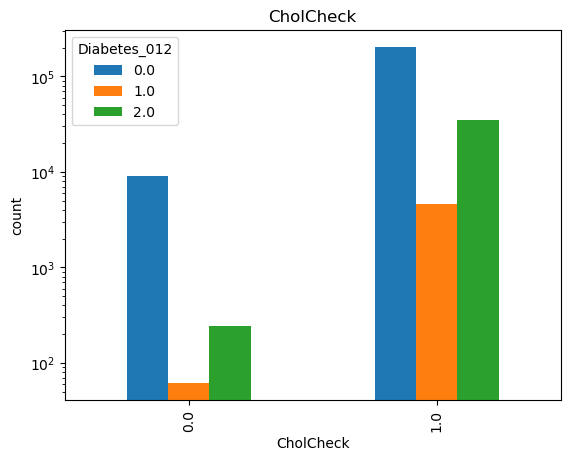

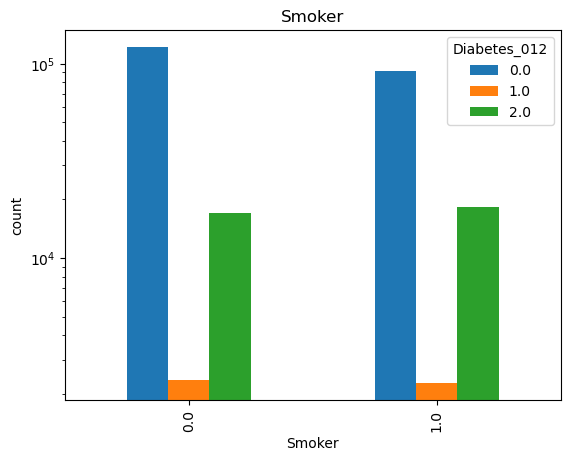

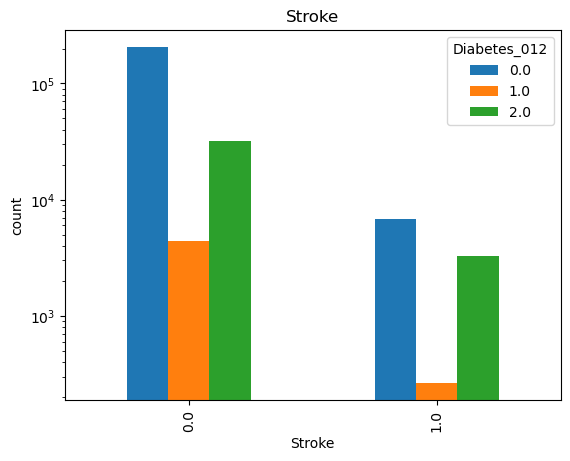

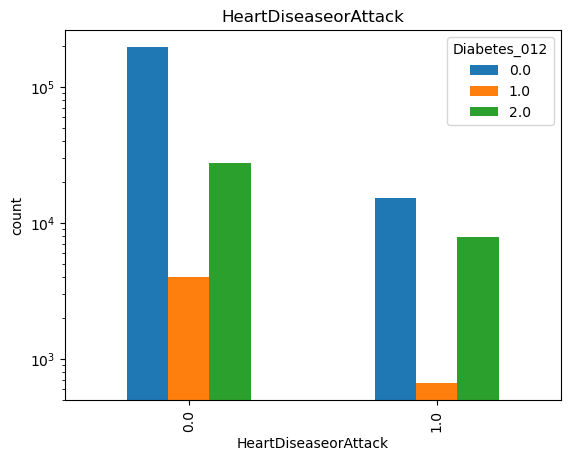

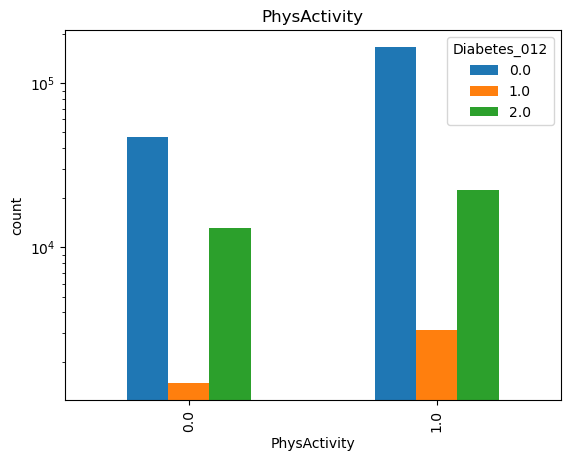

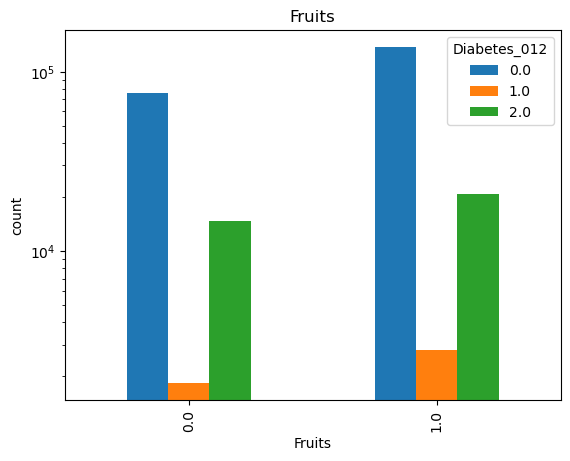

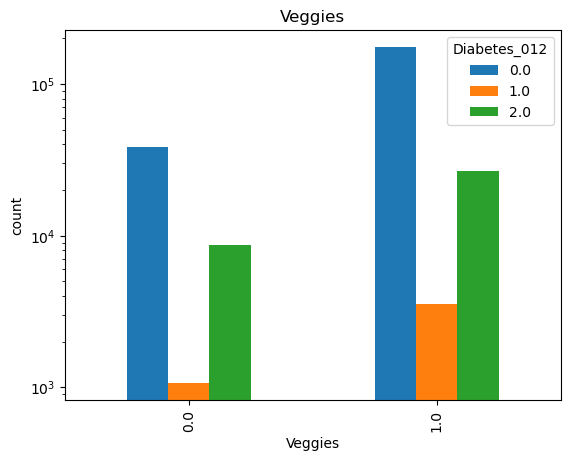

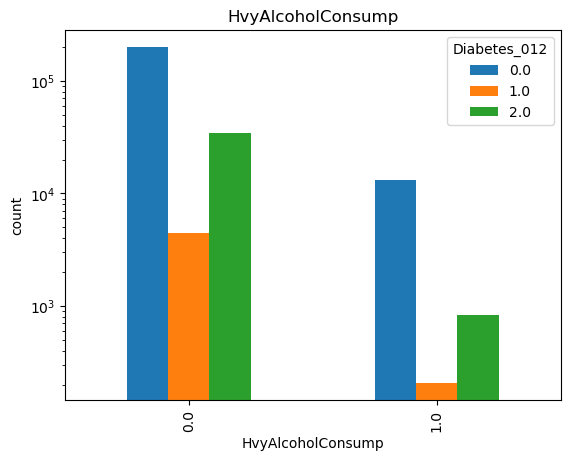

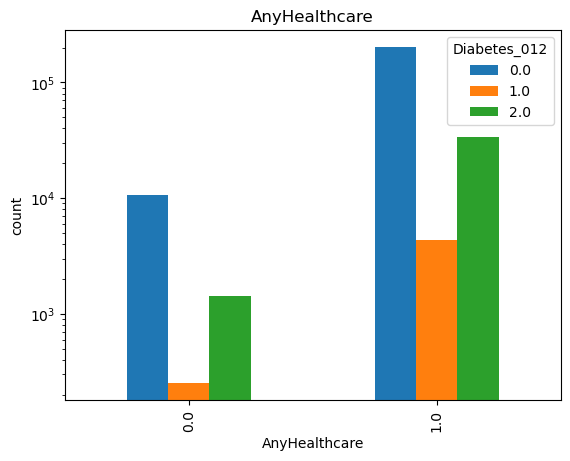

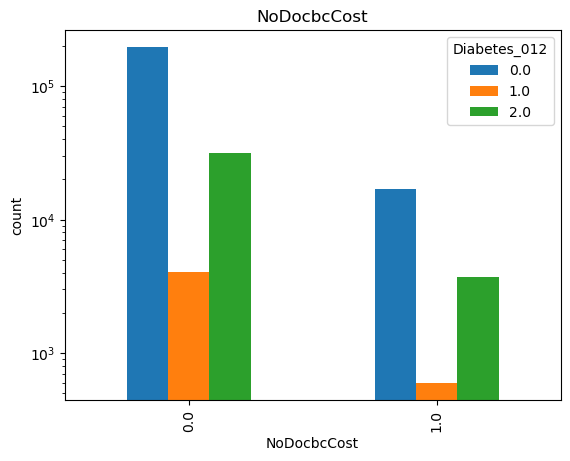

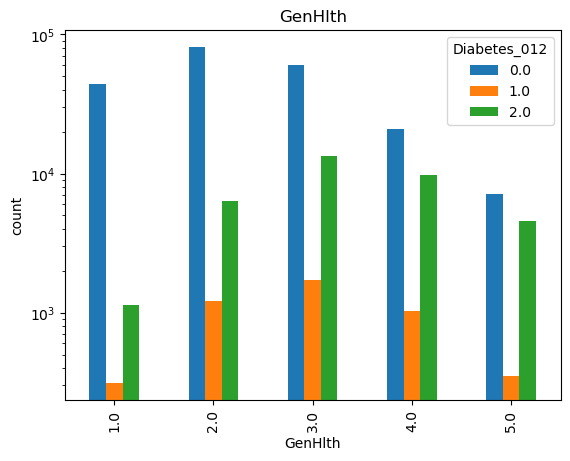

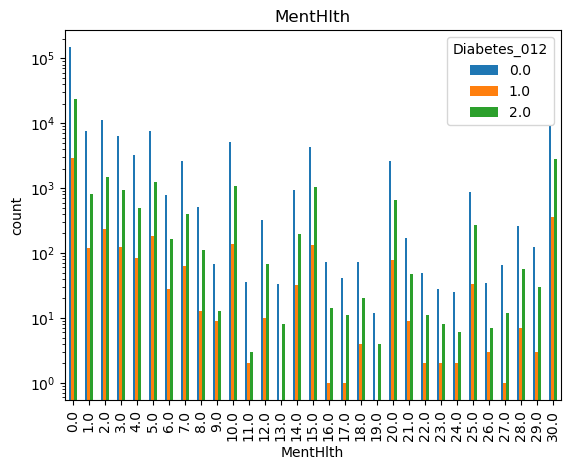

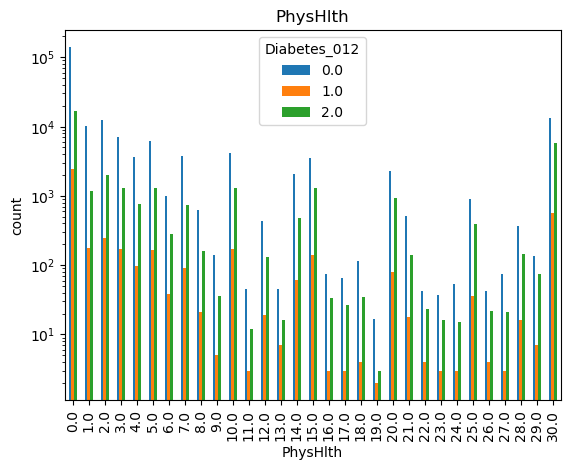

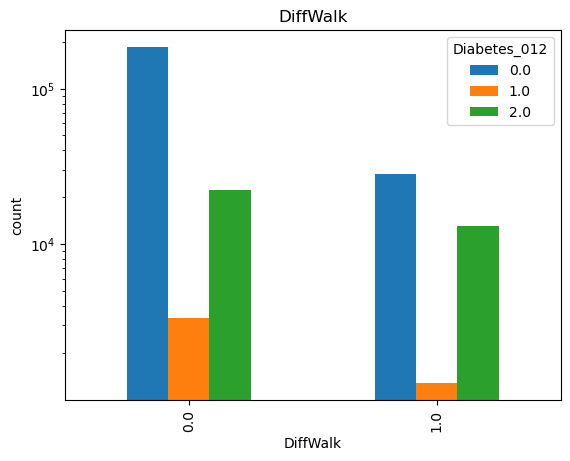

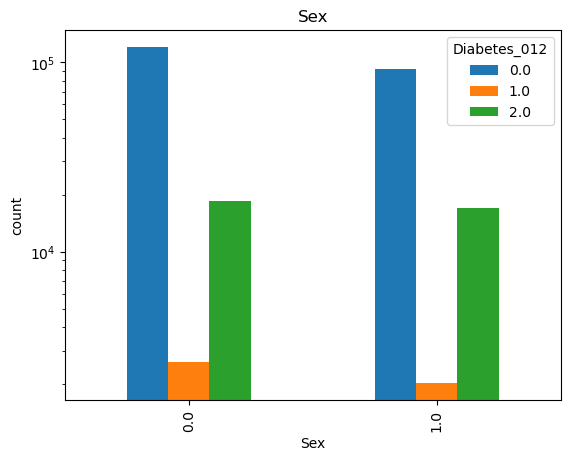

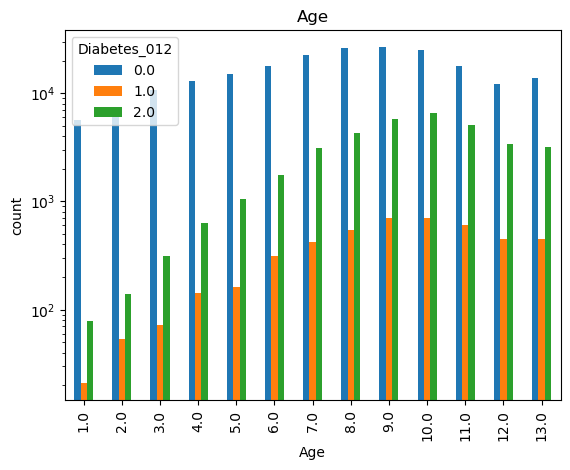

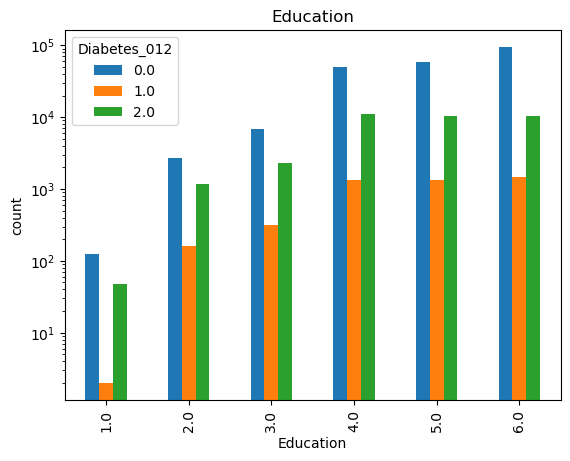

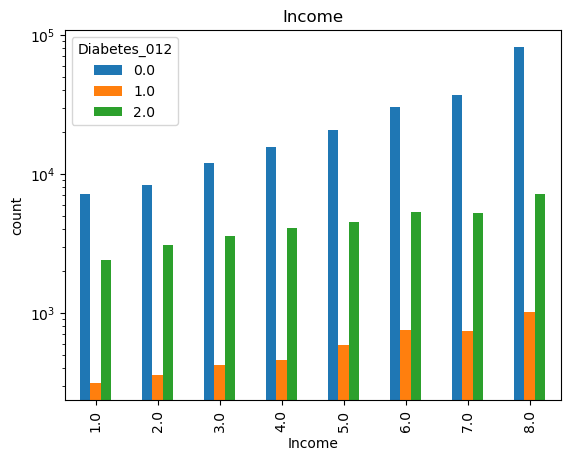

In [6]:
for column in featureList:
    data = df[['Diabetes_012', column]]
    g = data.groupby(['Diabetes_012', column])
    categoryTable = g.size().reset_index()
    categoryTable.columns = ['Diabetes_012', column, 'count']
    pivotTable = categoryTable.pivot(index = 'Diabetes_012', columns = column, values = 'count')
    pivotTable = pivotTable.fillna(0)
    # print(pivotTable)
    #plot if number of columns isn't too high
    numCol = len(pivotTable.columns)
    if(numCol < 32):
        pivotTable.T.plot(kind='bar')
        plt.title(column)
        plt.yscale('log')
        plt.ylabel('count')
        plt.show()

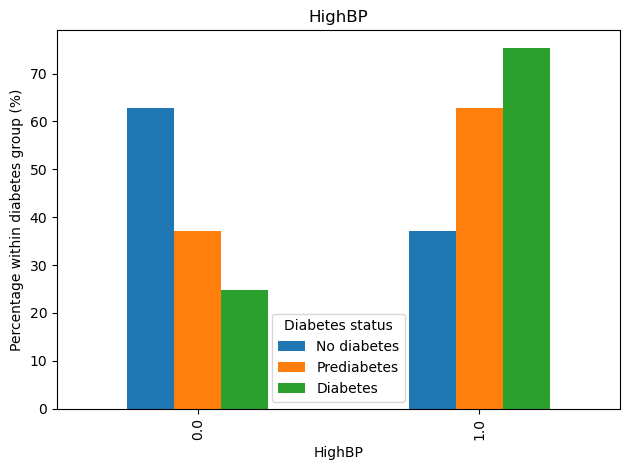

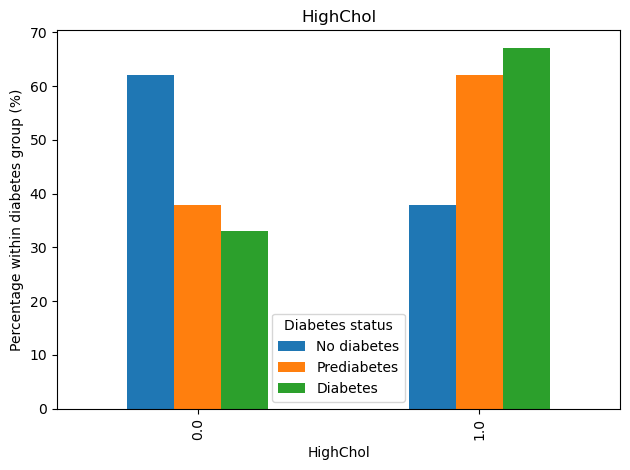

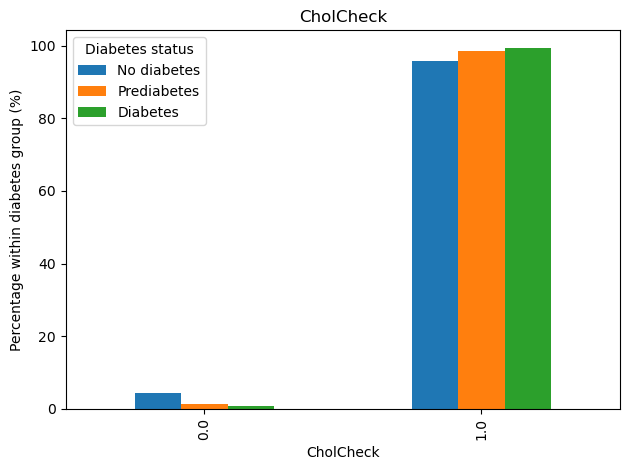

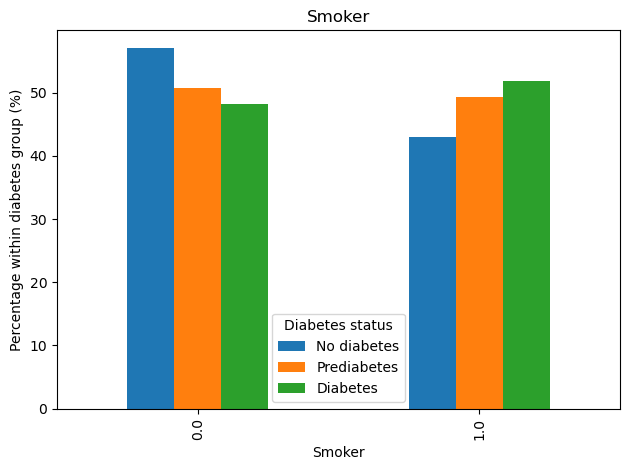

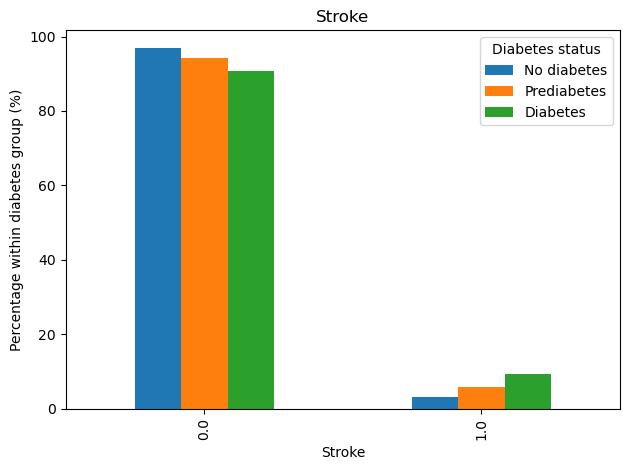

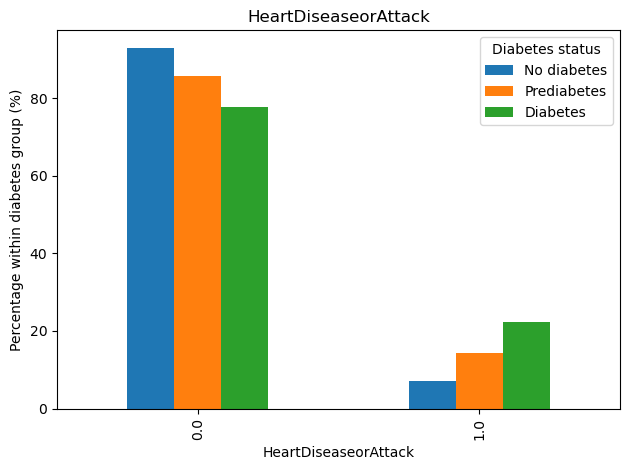

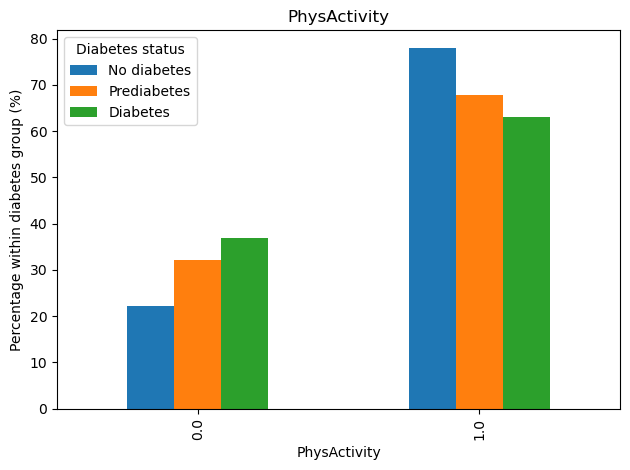

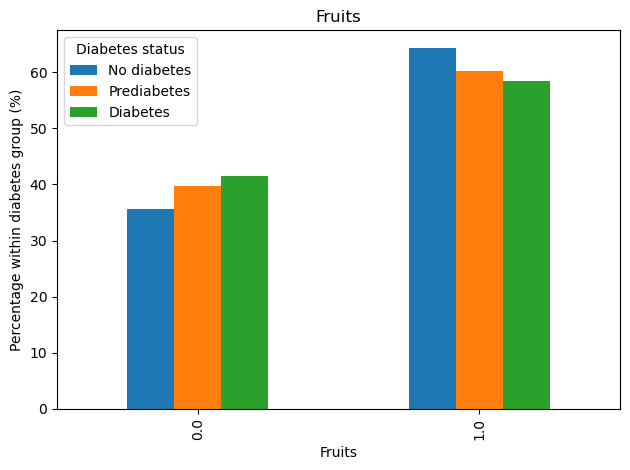

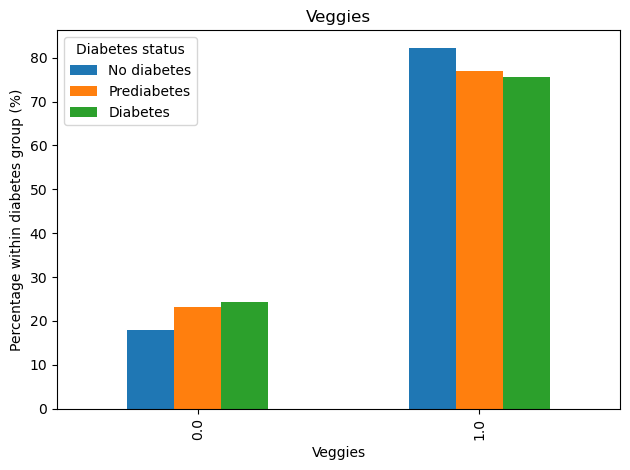

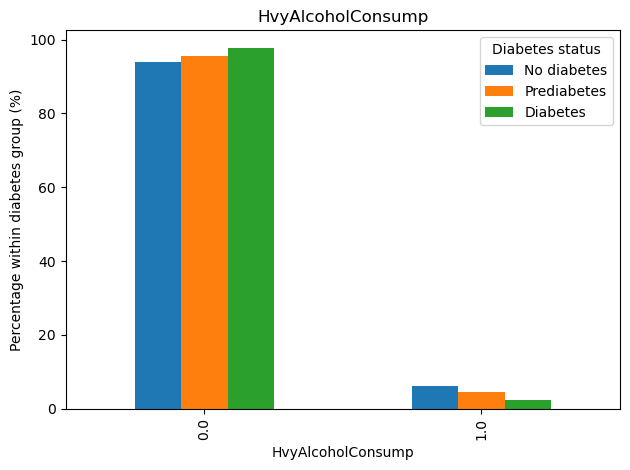

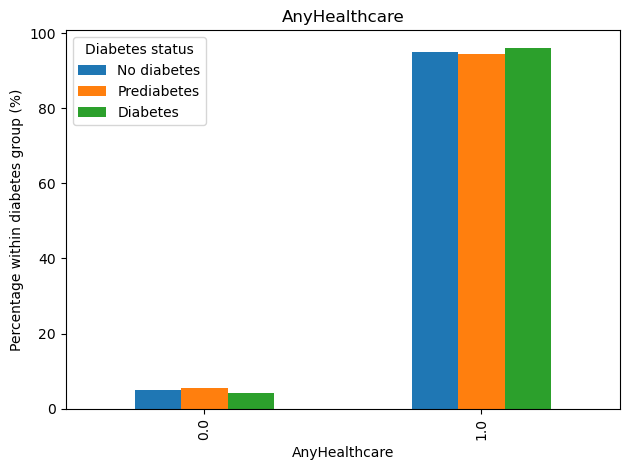

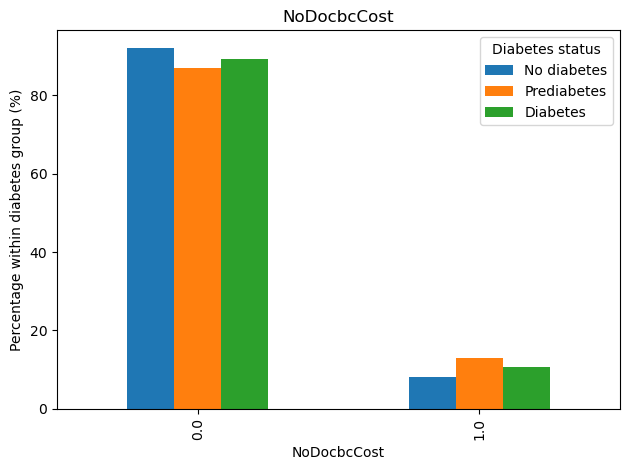

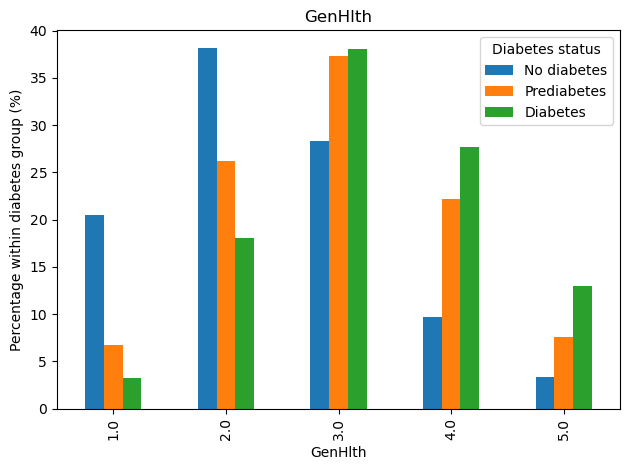

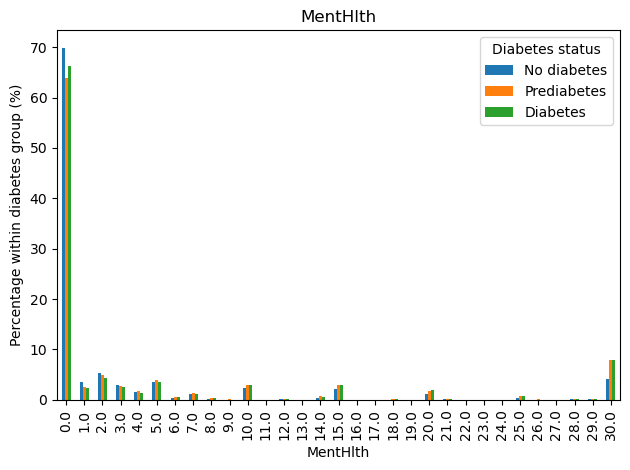

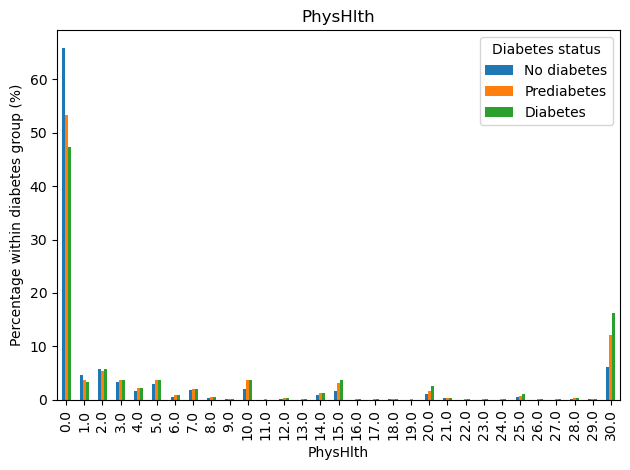

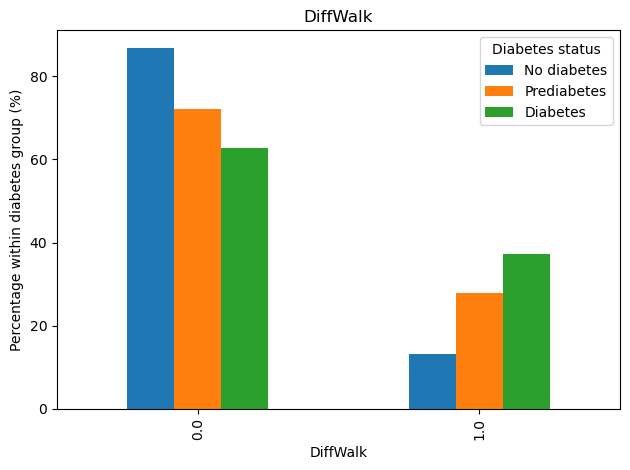

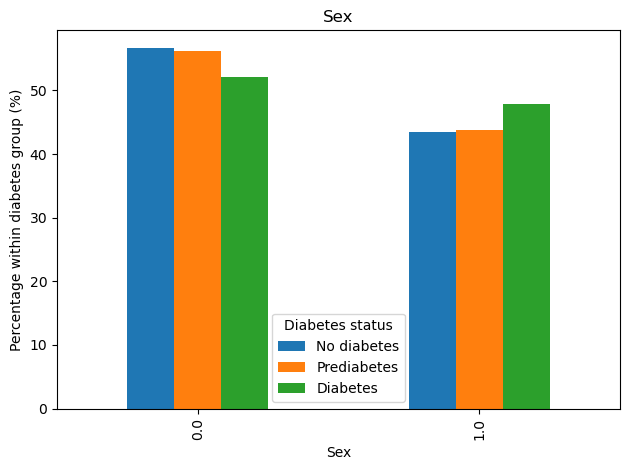

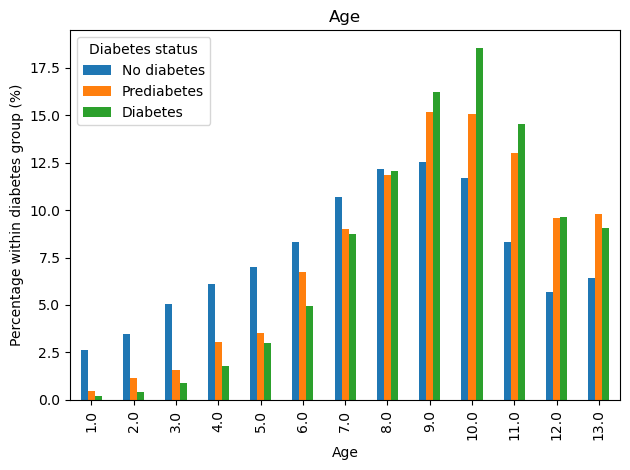

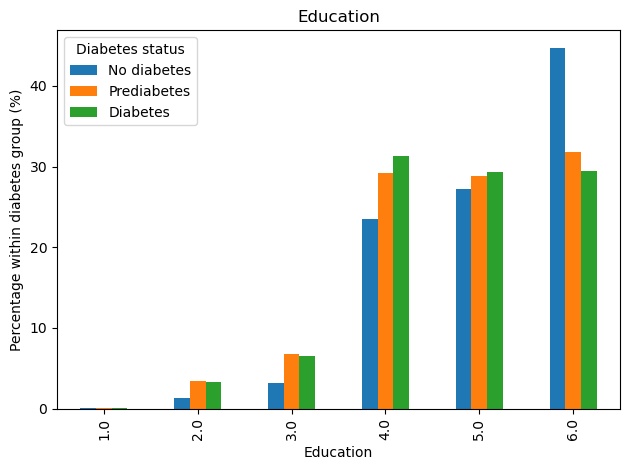

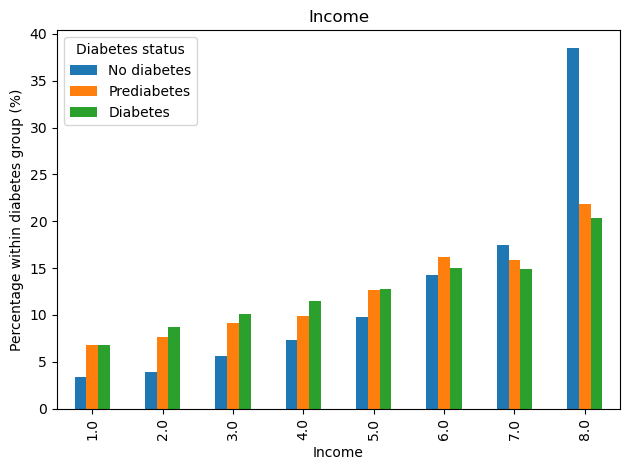

In [7]:
# Use %
featureList = df.drop(["Diabetes_012"], axis=1).columns.tolist()

for column in featureList:

    data = df[["Diabetes_012", column]]

    categoryTable = (
        data.groupby(["Diabetes_012", column])
        .size()
        .reset_index(name="count")
    )

    pivotTable = categoryTable.pivot(
        index="Diabetes_012",
        columns=column,
        values="count"
    ).fillna(0)

    # Convert counts into percentages
    percentageTable = pivotTable.div(
        pivotTable.sum(axis=1),
        axis=0
    ) * 100

    numCol = len(percentageTable.columns)

    # Plot only features with < 32 categories
    if numCol < 32:

        percentageTable.T.plot(kind="bar")

        plt.title(column)
        plt.xlabel(column)
        plt.ylabel("Percentage within diabetes group (%)")

        plt.legend(
            title="Diabetes status",
            labels=["No diabetes", "Prediabetes", "Diabetes"]
        )

        plt.tight_layout()

        plt.show()

# Relationship between BMI and diabetes status

**Is mean BMI significantly different among adults with no diabetes, prediabetes, and diabetes?**

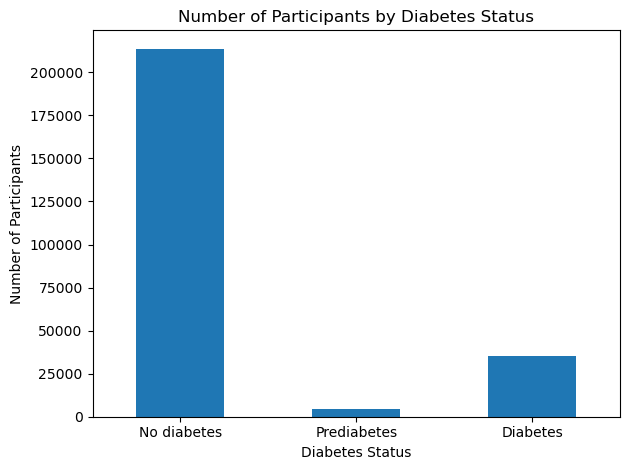

In [8]:
# Count the number of observations in each diabetes group
diabetes_counts = df["Diabetes_012"].value_counts().sort_index()

# Rename the categories
diabetes_counts.index = ["No diabetes", "Prediabetes", "Diabetes"]

# Create the bar chart
diabetes_counts.plot(kind="bar")

plt.title("Number of Participants by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Participants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The three diabetes groups are highly imbalanced:

* Most participants do not have diabetes.
* The prediabetes group is very small.
* The diabetes group is larger than the prediabetes group, but still much smaller than the no-diabetes group.

--> Raw counts can be misleading.  
--> Percentages should be used.

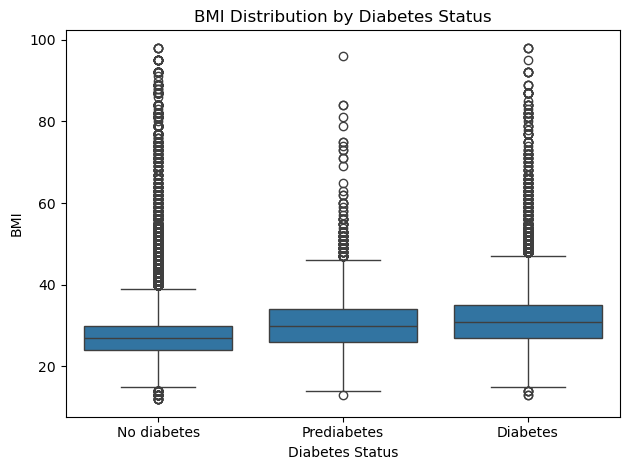

In [9]:
# Create readable diabetes labels
diabetes_labels = {
    0: "No diabetes",
    1: "Prediabetes",
    2: "Diabetes"
}

df["Diabetes_status"] = df["Diabetes_012"].map(diabetes_labels)

# Create a BMI boxplot
sns.boxplot(
    data=df,
    x="Diabetes_status",
    y="BMI",
    order=["No diabetes", "Prediabetes", "Diabetes"]
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()

BMI differs across diabetes-status groups.  
No diabetes --> lower median BMI.

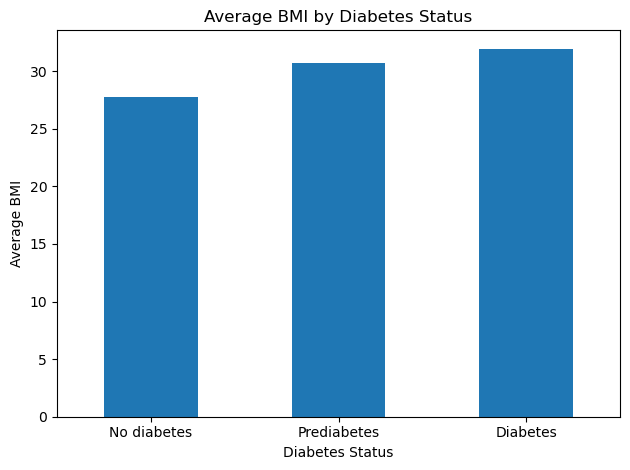

In [10]:
# Calculate the mean BMI for each diabetes group
mean_bmi = (
    df.groupby("Diabetes_status")["BMI"]
    .mean()
    .reindex(["No diabetes", "Prediabetes", "Diabetes"])
)

# Create the bar chart
mean_bmi.plot(kind="bar")

plt.title("Average BMI by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Average BMI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* No diabetes: the lowest average BMI, ~ 28.
* Prediabetes: a higher average BMI, ~ 31.
* Diabetes: the highest average BMI, ~ 32.

## Statistical test

$H_0$ The mean BMI is the same for the no-diabetes, prediabetes, and diabetes groups  
-->  
$H_0: \mu_{\text{No diabetes}} = \mu_{\text{Prediabetes}} = \mu_{\text{Diabetes}}$

$H_A$: At least one diabetes-status group has a different mean BMI.  

We use a significance level of $\alpha = 0.05$

In [11]:
group_order = ["No diabetes", "Prediabetes", "Diabetes"]

# Descriptive statistics in each group
bmi_groups = (
    df.groupby("Diabetes_status")["BMI"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(group_order)
)

bmi_groups.round(2)

,count,mean,median,std,min,max
Diabetes_status,,,,,,
No diabetes,213703,27.74,27.0,6.26,12.0,98.0
Prediabetes,4631,30.72,30.0,6.96,13.0,96.0
Diabetes,35346,31.94,31.0,7.36,13.0,98.0


### ANOVA

**Condition 1: The observations are independent within and across groups.**

The observations are assumed to be independent.

**Condition 2: The data within each group are nearly normal**

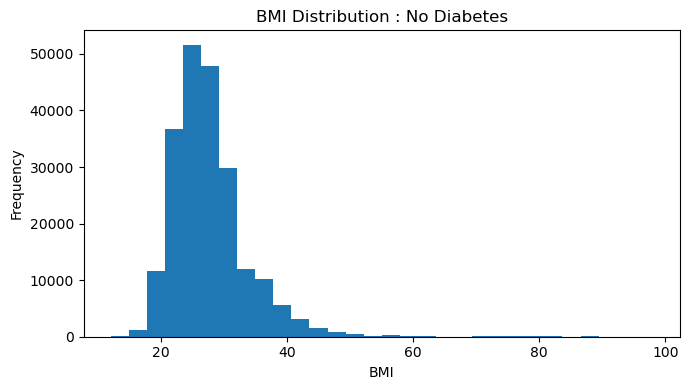

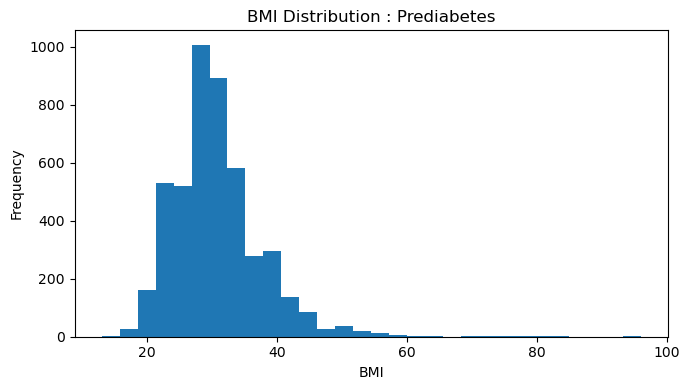

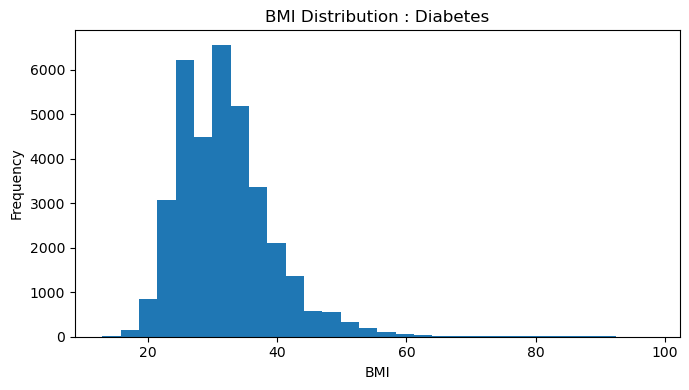

In [12]:
# Create BMI groups
no_diabetes_bmi = df.loc[df["Diabetes_012"] == 0, "BMI"]
prediabetes_bmi = df.loc[df["Diabetes_012"] == 1, "BMI"]
diabetes_bmi = df.loc[df["Diabetes_012"] == 2, "BMI"]

groups = {
    "No Diabetes": no_diabetes_bmi,
    "Prediabetes": prediabetes_bmi,
    "Diabetes": diabetes_bmi
}

for group_name, bmi_values in groups.items():
    plt.figure(figsize=(7, 4))
    plt.hist(bmi_values, bins=30)
    plt.title(f"BMI Distribution : {group_name}")
    plt.xlabel("BMI")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

The BMI distributions are not perfectly normal and are slightly skewed to the right.  
However, each group has a large sample size, so the normality condition is acceptable for ANOVA.

**Condition 3: The variability across the groups should be about equal**

In [13]:
# Compare the BMI standard deviations
bmi_std = (
    df.groupby("Diabetes_status")["BMI"]
    .std()
    .reindex(["No diabetes", "Prediabetes", "Diabetes"])
)

bmi_std.round(2)

Diabetes_status
No diabetes    6.26
Prediabetes    6.96
Diabetes       7.36
Name: BMI, dtype: float64

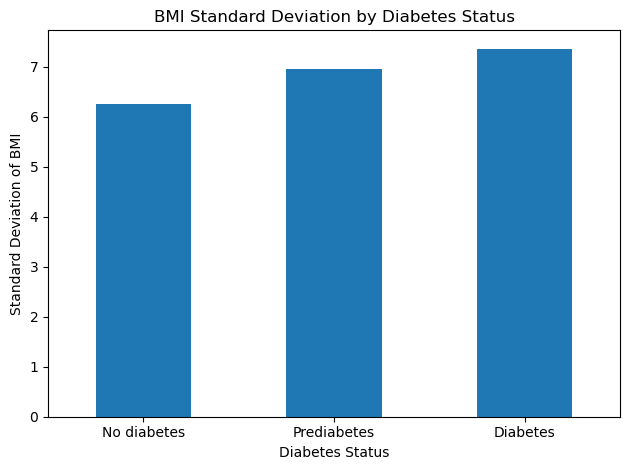

In [14]:
bmi_std.plot(kind="bar")

plt.title("BMI Standard Deviation by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Standard Deviation of BMI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The BMI standard deviations are similar across the three groups   
--> the variability condition is reasonably satisfied.

### One-Way ANOVA

In [15]:
from scipy.stats import f_oneway

f_statistic, p_value = f_oneway(
    no_diabetes_bmi,
    prediabetes_bmi,
    diabetes_bmi
)

print(f"F-statistic = {f_statistic:.2f}")
print(f"p-value = {p_value:.3e}")

F-statistic = 6768.36
p-value = 0.000e+00


Since the p-value < $\alpha = 0.05$, we reject $H_0$.

There is sufficient evidence that at least one diabetes-status group has a different mean BMI.

The mean BMI increases across the three groups:

- No diabetes: 27.74
- Prediabetes: 30.72
- Diabetes: 31.94

The results show a statistically significant association between diabetes status and mean BMI.

Because the data are observational, this analysis shows an association but does not prove that diabetes causes a higher BMI or that a higher BMI causes diabetes.

## Predictive Model: Logistic Regression

We now examine whether BMI can be used to predict diabetes status.

- Predictor: BMI
- Outcome: Diabetes_binary

In [16]:
df_binary = pd.read_csv("diabetes_binary.csv")

df_binary[["Diabetes_binary", "BMI"]].head()

,Diabetes_binary,BMI
0,0.0,40.0
1,0.0,25.0
2,0.0,28.0
3,0.0,27.0
4,0.0,24.0


### Class Distribution

In [17]:
df_binary["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

In [18]:
# Calculate the percentage of participants in each diabetes class
df_binary["Diabetes_binary"].value_counts(normalize=True) * 100

Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64

The dataset is imbalanced, with fewer diabetes cases than non-diabetes cases.

Therefore, accuracy alone may be misleading. Recall, precision, and F1-score should also be examined.

In [19]:
# Define the predictor and outcome
X = df_binary[["BMI"]]
y = df_binary["Diabetes_binary"]

### Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape[0])
print("Test set:", X_test.shape[0])

Training set: 202944
Test set: 50736


The model is **trained on 80%** of the data and **evaluated on the remaining 20%**.

The test set provides an evaluation using observations that were not used to train the model.

### Logistic Regression Model

In [21]:
from sklearn.linear_model import LogisticRegression

# Train the logistic regression model
model = LogisticRegression()

model.fit(X_train, y_train);

### Predictions

In [22]:
# Predict diabetes status on the test set
y_pred = model.predict(X_test)

y_pred[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

### Model Evaluation

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8580692210659098

Confusion Matrix:
[[43432   235]
 [ 6966   103]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     43667
         1.0       0.30      0.01      0.03      7069

    accuracy                           0.86     50736
   macro avg       0.58      0.50      0.48     50736
weighted avg       0.78      0.86      0.80     50736



The model has an accuracy of 85.8%, but this result is misleading because the dataset is imbalanced.

For participants with diabetes:

- Precision = 0.30
- Recall = 0.01
- F1-score = 0.03

The model identifies only about 1% of the actual diabetes cases. Therefore, BMI alone is not sufficient to build a useful diabetes prediction model.

### Confusion Matrix

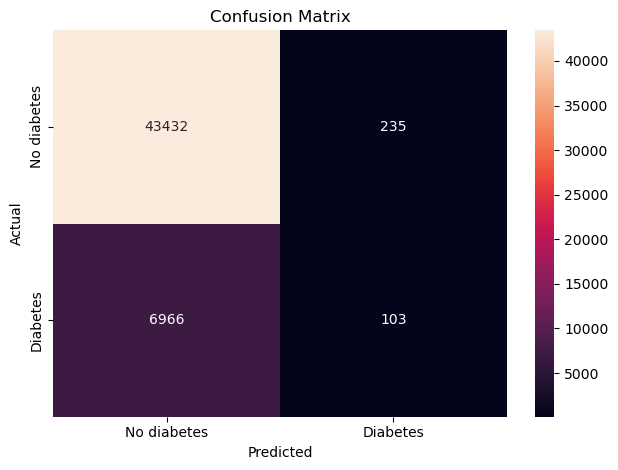

In [24]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

The model correctly classifies most non-diabetes cases but misses most diabetes cases.

BMI alone is therefore not sufficient for reliable diabetes prediction.

## Multiple-Predictor Logistic Regression

A second logistic regression model is built using additional health indicators to determine whether prediction performance improves.

In [25]:
# Select multiple predictors
features = [
    "BMI",
    "HighBP",
    "HighChol",
    "Age",
    "GenHlth",
    "PhysActivity"
]

X_multi = df_binary[features]
y_multi = df_binary["Diabetes_binary"]

### Backward Elimination

In [26]:
import statsmodels.api as sm

# Add a constant for the intercept
X_multi_sm = sm.add_constant(X_multi)

# Fit the initial logistic regression model
logit_model = sm.Logit(y_multi, X_multi_sm)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.323755
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:        Diabetes_binary   No. Observations:               253680
Model:                          Logit   Df Residuals:                   253673
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                  0.1981
Time:                        12:10:22   Log-Likelihood:                -82130.
converged:                       True   LL-Null:                   -1.0242e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -7.2721      0.046   -156.672      0.000      -7.363      -7.181
BMI              0.0623

### Multiple-Predictor Model Evaluation

In [27]:
# Split the data into training and test sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=42,
    stratify=y_multi
)

In [28]:
# Train the multiple-predictor logistic regression model
model_multi = LogisticRegression(max_iter=1000)

model_multi.fit(X_train_multi, y_train_multi);

In [29]:
# Make predictions
y_pred_multi = model_multi.predict(X_test_multi)

In [30]:
print("Accuracy:", accuracy_score(y_test_multi, y_pred_multi))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_multi, y_pred_multi))

print("\nClassification Report:")
print(classification_report(y_test_multi, y_pred_multi))

Accuracy: 0.8615184484389783

Confusion Matrix:
[[42732   935]
 [ 6091   978]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.51      0.14      0.22      7069

    accuracy                           0.86     50736
   macro avg       0.69      0.56      0.57     50736
weighted avg       0.82      0.86      0.83     50736



The multiple-predictor model performs better than the BMI-only model.

For diabetes cases, recall increases from 1% to 14%, and the F1-score increases from 0.03 to 0.22.

However, the model still misses most diabetes cases. Therefore, its predictive performance remains limited.

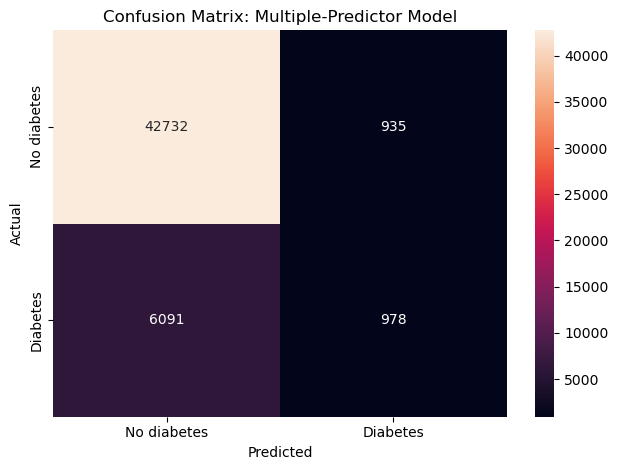

In [31]:
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Multiple-Predictor Model")
plt.tight_layout()
plt.show()

### Random Oversampling

In [32]:
from sklearn.utils import resample

# Combine training data
train_data = X_train_multi.copy()
train_data["Diabetes_binary"] = y_train_multi.values

# Separate classes
train_no_diabetes = train_data[
    train_data["Diabetes_binary"] == 0
]

train_diabetes = train_data[
    train_data["Diabetes_binary"] == 1
]

# Oversample the diabetes class
train_diabetes_oversampled = resample(
    train_diabetes,
    replace=True,
    n_samples=len(train_no_diabetes),
    random_state=42
)

# Combine and shuffle
train_balanced = pd.concat([
    train_no_diabetes,
    train_diabetes_oversampled
]).sample(frac=1, random_state=42)

train_balanced["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64

The diabetes class was oversampled by randomly duplicating diabetes observations in the training set.

This creates a balanced training set with 174,667 observations in each class. The test set remains unchanged so that model performance can be evaluated on the original class distribution.

### Oversampled Logistic Regression Model

In [33]:
# Separate predictors and target
X_train_balanced = train_balanced[features]
y_train_balanced = train_balanced["Diabetes_binary"]

# Train the model
model_balanced = LogisticRegression(max_iter=1000)

model_balanced.fit(X_train_balanced, y_train_balanced);

In [34]:
# Make predictions on the original test set
y_pred_balanced = model_balanced.predict(X_test_multi)

In [35]:
print("Accuracy:", accuracy_score(y_test_multi, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_multi, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test_multi, y_pred_balanced))

Accuracy: 0.7232537054556922

Confusion Matrix:
[[31324 12343]
 [ 1698  5371]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.30      0.76      0.43      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.72      0.76     50736



The oversampled model improves the detection of diabetes cases.

Recall for diabetes increases to 0.76, meaning that the model identifies about 76% of the actual diabetes cases.

However, precision decreases to 0.30 and accuracy decreases to 0.72. This means that the model detects more diabetes cases, but it also produces more false positive predictions.

### Backward Elimination After Oversampling

In [36]:
# Add the intercept
X_train_balanced_sm = sm.add_constant(X_train_balanced)

# Fit logistic regression on the balanced training set
logit_balanced = sm.Logit(
    y_train_balanced,
    X_train_balanced_sm
)

result_balanced = logit_balanced.fit()

print(result_balanced.summary())

Optimization terminated successfully.
         Current function value: 0.521362
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        Diabetes_binary   No. Observations:               349334
Model:                          Logit   Df Residuals:                   349327
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                  0.2478
Time:                        12:10:29   Log-Likelihood:            -1.8213e+05
converged:                       True   LL-Null:                   -2.4214e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -6.2594      0.031   -199.415      0.000      -6.321      -6.198
BMI              0.0764

All predictors have p-values < 0.05.

Therefore, no variable is removed during backward elimination after oversampling.

## Model Comparison

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": [
        "BMI only",
        "Multiple predictors",
        "Multiple predictors with oversampling"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_multi, y_pred_multi),
        accuracy_score(y_test_multi, y_pred_balanced)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test_multi, y_pred_multi),
        precision_score(y_test_multi, y_pred_balanced)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test_multi, y_pred_multi),
        recall_score(y_test_multi, y_pred_balanced)
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test_multi, y_pred_multi),
        f1_score(y_test_multi, y_pred_balanced)
    ]
})

model_comparison.round(2)

,Model,Accuracy,Precision,Recall,F1-score
0,BMI only,0.86,0.30,0.01,0.03
1,Multiple predictors,0.86,0.51,0.14,0.22
2,Multiple predictors with oversampling,0.72,0.30,0.76,0.43


The multiple-predictor model improves precision and recall compared with the BMI-only model.

The oversampled model achieves the highest recall and F1-score for diabetes cases. However, its accuracy and precision are lower because it produces more false positive predictions.

Therefore, the oversampled model is preferred when identifying as many diabetes cases as possible is the main priority.

## Conclusion

**Two Modeling Goals**

### Understanding

The ANOVA and the multiple-predictor model fitted on the original data help explain the associations between health indicators and diabetes status.

### Prediction

The oversampled model is used to improve the detection of diabetes cases. It achieves higher recall, but it also produces more false positives.

Therefore, the original data are more appropriate for understanding associations, while oversampling is more useful for prediction.